## IMPORT

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import glob
import random
from pathlib import Path
from google.colab import drive


## Akuisisi Data

In [ ]:
drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/Project_PCD'

DATASET_PATH = os.path.join(PROJECT_ROOT, 'MMU-Iris-Database')   # Folder dataset
OUTPUT_PATH  = os.path.join(PROJECT_ROOT, 'output')              # Folder output

TRAIN_PATH   = os.path.join(OUTPUT_PATH, 'split', 'train')       # Sub-folder output untuk tiap tahap
TEST_PATH    = os.path.join(OUTPUT_PATH, 'split', 'test')
PREPROC_PATH = os.path.join(OUTPUT_PATH, 'preprocessed')
SEG_PATH     = os.path.join(OUTPUT_PATH, 'segmented')
NORM_PATH    = os.path.join(OUTPUT_PATH, 'normalized')
AUG_PATH     = os.path.join(OUTPUT_PATH, 'augmented')

for folder in [TRAIN_PATH, TEST_PATH, PREPROC_PATH, SEG_PATH, NORM_PATH, AUG_PATH]:
    os.makedirs(folder, exist_ok=True) # Buat semua folder output (jika belum ada)

random.seed(42) # Seed untuk reprodusibilitas
np.random.seed(42)

print(f"Output akan disimpan di:")
print(f"   {OUTPUT_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output akan disimpan di:
   /content/drive/MyDrive/Project_PCD/output


In [ ]:
def explore_dataset(dataset_path):
    dataset_info = {}
    total_images = 0

    for person_id in sorted(os.listdir(dataset_path)):            # Iterasi tiap folder indiviu
        person_folder = os.path.join(dataset_path, person_id)
        if not os.path.isdir(person_folder):
            continue

        left_images  = []
        right_images = []

        left_folder = os.path.join(person_folder, 'left')  # Cari gambar mata kiri (folder 'left')
        if os.path.exists(left_folder):
            for ext in ['*.bmp', '*.BMP', '*.jpg', '*.JPG', '*.png', '*.PNG']:  # Cari semua ekstensi gambar yang umum
                left_images += glob.glob(os.path.join(left_folder, ext))
            left_images = sorted(left_images)

        right_folder = os.path.join(person_folder, 'right') # Cari gambar mata kanan (folder 'right')
        if os.path.exists(right_folder):
            for ext in ['*.bmp', '*.BMP', '*.jpg', '*.JPG', '*.png', '*.PNG']:
                right_images += glob.glob(os.path.join(right_folder, ext))
            right_images = sorted(right_images)

        if left_images or right_images:
            dataset_info[person_id] = {'left': left_images, 'right': right_images}
            total_images += len(left_images) + len(right_images)

    return dataset_info, total_images


dataset_info, total_images = explore_dataset(DATASET_PATH)

print("HASIL EKSPLORASI DATASET MMU IRIS")
print("=" * 45)
print(f"Jumlah individu   : {len(dataset_info)}")
print(f"Total gambar      : {total_images}")
print()

print("Sampel 5 individu pertama:")
for i, (pid, data) in enumerate(list(dataset_info.items())[:5]):
    print(f"  Individu {pid:>3}: {len(data['left'])} mata kiri, {len(data['right'])} mata kanan")


HASIL EKSPLORASI DATASET MMU IRIS
Jumlah individu   : 45
Total gambar      : 450

Sampel 5 individu pertama:
  Individu   1: 5 mata kiri, 5 mata kanan
  Individu  10: 5 mata kiri, 5 mata kanan
  Individu  11: 5 mata kiri, 5 mata kanan
  Individu  12: 5 mata kiri, 5 mata kanan
  Individu  13: 5 mata kiri, 5 mata kanan


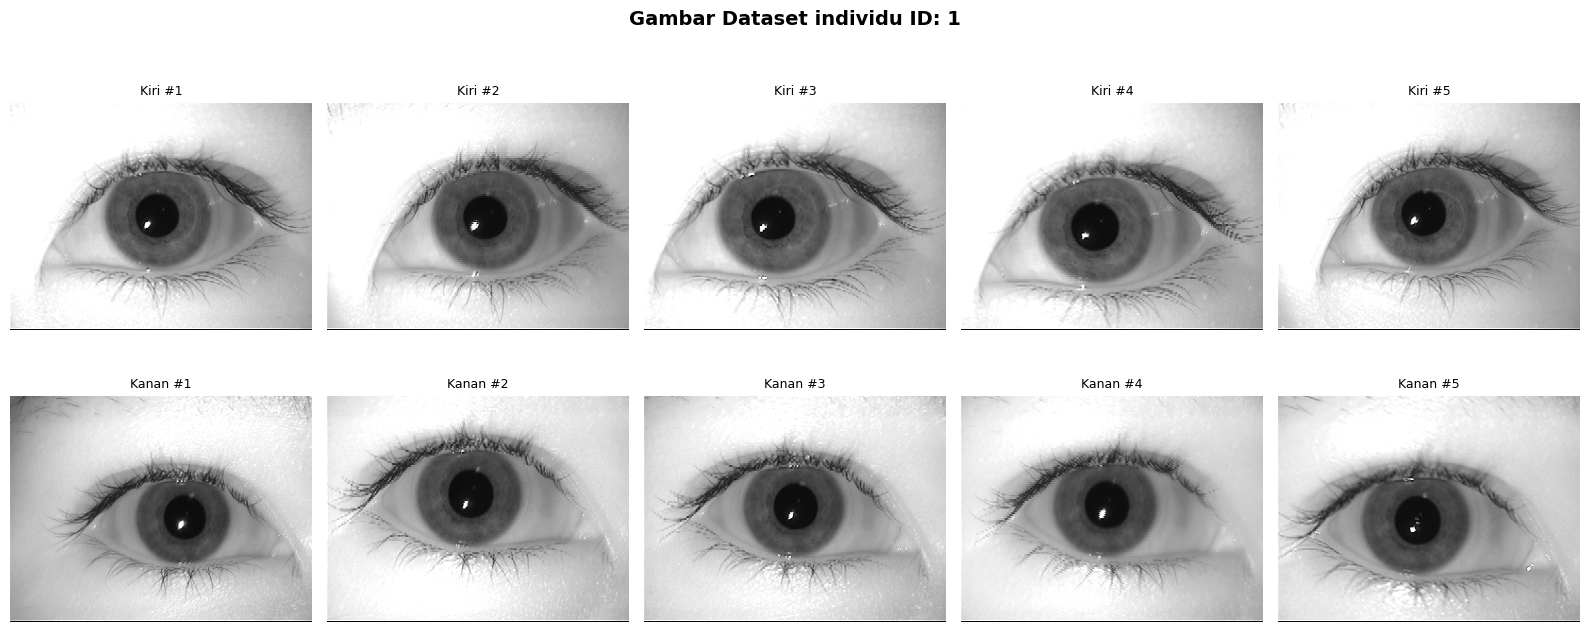

Visualisasi tersimpan di Google Drive: /content/drive/MyDrive/Project_PCD/output/eksplorasi_dataset.png


In [ ]:
# cek gambar dari dataset (1 individu, kiri & kanan)

sample_pid  = list(dataset_info.keys())[0]
sample_data = dataset_info[sample_pid]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(f'Gambar Dataset individu ID: {sample_pid}', fontsize=14, fontweight='bold')

for i in range(5):
    if i < len(sample_data['left']):   # Baris atas: mata kiri
        img_l = cv2.imread(sample_data['left'][i], cv2.IMREAD_GRAYSCALE)   # Baca gambar dari Google Drive
        if img_l is not None:
            axes[0, i].imshow(img_l, cmap='gray')
            axes[0, i].set_title(f'Kiri #{i+1}', fontsize=9)
    axes[0, i].axis('off')

    if i < len(sample_data['right']):   # Baris bawah: mata kanan
        img_r = cv2.imread(sample_data['right'][i], cv2.IMREAD_GRAYSCALE)
        if img_r is not None:
            axes[1, i].imshow(img_r, cmap='gray')
            axes[1, i].set_title(f'Kanan #{i+1}', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Mata Kiri', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Mata Kanan', fontsize=11, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(OUTPUT_PATH, 'eksplorasi_dataset.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Visualisasi tersimpan di Google Drive: {save_path}")


## Split Data

In [ ]:
def split_dataset(dataset_info, train_path, test_path,
                  n_train_left=4, n_train_right=4):
    split_summary = {}

    for person_id, data in dataset_info.items():
        # Buat folder tujuan
        for split in ['train', 'test']:
            for side in ['left', 'right']:
                folder = os.path.join(
                    train_path if split == 'train' else test_path,
                    person_id, side
                )
                os.makedirs(folder, exist_ok=True)

        split_summary[person_id] = {'train': {'left': [], 'right': []},
                                    'test':  {'left': [], 'right': []}}

        # Mata KIRI
        left_imgs = data['left'].copy()
        random.shuffle(left_imgs)           # Acak agar test tidak selalu foto yang sama
        train_left = left_imgs[:n_train_left]   # 4 foto → train
        test_left  = left_imgs[n_train_left:]   # 1 foto → test

        for img_path in train_left:
            fname = os.path.basename(img_path)
            dst   = os.path.join(train_path, person_id, 'left', fname)
            shutil.copy2(img_path, dst)         # copy2 = salin beserta metadata
            split_summary[person_id]['train']['left'].append(dst)

        for img_path in test_left:
            fname = os.path.basename(img_path)
            dst   = os.path.join(test_path, person_id, 'left', fname)
            shutil.copy2(img_path, dst)
            split_summary[person_id]['test']['left'].append(dst)

        # Mata KANAN
        right_imgs = data['right'].copy()
        random.shuffle(right_imgs)
        train_right = right_imgs[:n_train_right]
        test_right  = right_imgs[n_train_right:]

        for img_path in train_right:
            fname = os.path.basename(img_path)
            dst   = os.path.join(train_path, person_id, 'right', fname)
            shutil.copy2(img_path, dst)
            split_summary[person_id]['train']['right'].append(dst)

        for img_path in test_right:
            fname = os.path.basename(img_path)
            dst   = os.path.join(test_path, person_id, 'right', fname)
            shutil.copy2(img_path, dst)
            split_summary[person_id]['test']['right'].append(dst)

    return split_summary

split_summary = split_dataset(dataset_info, TRAIN_PATH, TEST_PATH,
                              n_train_left=4, n_train_right=4)

total_train = sum(len(v['train']['left']) + len(v['train']['right']) # Hitung total
                  for v in split_summary.values())
total_test  = sum(len(v['test']['left'])  + len(v['test']['right'])
                  for v in split_summary.values())

print("HASIL SPLIT DATA")
print("=" * 45)
print(f"Total data TRAIN : {total_train} gambar")
print(f"  Per individu   : 8 gambar (4 kiri + 4 kanan)")
print()
print(f"Total data TEST  : {total_test} gambar")
print(f"  Per individu   : 2 gambar (1 kiri + 1 kanan)")
print()

print(f" Data Split tersimpan di Google Drive:")
print(f"   Train → {TRAIN_PATH}")
print(f"   Test  → {TEST_PATH}")


HASIL SPLIT DATA
Total data TRAIN : 360 gambar
  Per individu   : 8 gambar (4 kiri + 4 kanan)

Total data TEST  : 90 gambar
  Per individu   : 2 gambar (1 kiri + 1 kanan)

 Data Split tersimpan di Google Drive:
   Train → /content/drive/MyDrive/Project_PCD/output/split/train
   Test  → /content/drive/MyDrive/Project_PCD/output/split/test


## Pra-Pemrosesan Citra

Tujuan:
Membersihkan citra dari gangguan agar tahap segmentasi lebih akurat.

Dua langkah utama:

**A. Penghapusan Specular Reflection (Pantulan Cahaya)**
> Piksel yang sangat terang (pantulan lampu/sinar) dapat mengganggu deteksi tepi iris. Kita deteksi piksel terang, perluas areanya dengan *dilation*, lalu perbaiki dengan *inpainting* (mengisi area yang dihapus dengan tekstur sekitarnya).

**B. CLAHE (Contrast Limited Adaptive Histogram Equalization)**
> Metode peningkatan kontras yang bekerja secara lokal (per tile/kotak kecil), bukan global. Ini efektif untuk citra iris yang sering memiliki distribusi kecerahan tidak merata.

In [ ]:
def remove_specular_reflection(gray_img, bright_thresh=240, dilate_iter=3):
    _, mask = cv2.threshold(gray_img, bright_thresh, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_dilated = cv2.dilate(mask, kernel, iterations=dilate_iter)

    result = cv2.inpaint(gray_img, mask_dilated, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    return result, mask_dilated


def apply_clahe(gray_img, clip_limit=2.0, tile_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    result = clahe.apply(gray_img)
    return result


def preprocess_image(img_path, bright_thresh=240, clip_limit=2.0):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Baca citra dalam mode grayscale
    if img is None:
        raise ValueError(f"Gagal membaca: {img_path}")

    img_no_spec, spec_mask = remove_specular_reflection(img, bright_thresh)  # Hapus specular reflection
    img_clahe = apply_clahe(img_no_spec, clip_limit) # Tingkatkan kontras dengan CLAHE
    return img, img_no_spec, spec_mask, img_clahe

print("Fungsi pra-pemrosesan siap!")

Fungsi pra-pemrosesan siap!


Memproses gambar: aeval4.bmp


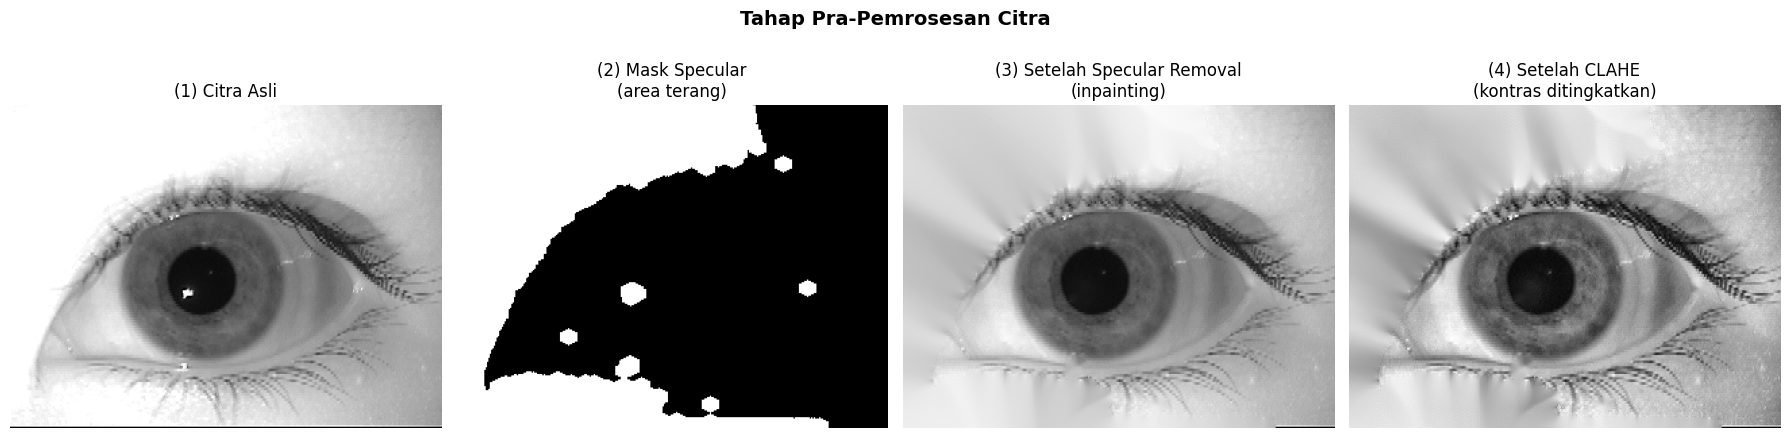

Visualisasi tersimpan di Google Drive: /content/drive/MyDrive/Project_PCD/output/demo_preprocessing.png


In [ ]:
# Visualisasi hasil pra-pemrosesan pada 1 gambar sampel

sample_pid   = list(split_summary.keys())[0]  # Ambil gambar pertama dari hasil split train
sample_imgs  = split_summary[sample_pid]['train']['left']
sample_path  = sample_imgs[0]

print(f"Memproses gambar: {os.path.basename(sample_path)}")
img_orig, img_no_spec, spec_mask, img_clahe = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Tahap Pra-Pemrosesan Citra', fontsize=14, fontweight='bold')

axes[0].imshow(img_orig,    cmap='gray'); axes[0].set_title('(1) Citra Asli');            axes[0].axis('off')
axes[1].imshow(spec_mask,   cmap='gray'); axes[1].set_title('(2) Mask Specular\n(area terang)'); axes[1].axis('off')
axes[2].imshow(img_no_spec, cmap='gray'); axes[2].set_title('(3) Setelah Specular Removal\n(inpainting)'); axes[2].axis('off')
axes[3].imshow(img_clahe,   cmap='gray'); axes[3].set_title('(4) Setelah CLAHE\n(kontras ditingkatkan)'); axes[3].axis('off')

plt.tight_layout()
save_path = os.path.join(OUTPUT_PATH, 'demo_preprocessing.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"Visualisasi tersimpan di Google Drive: {save_path}")


In [ ]:
# Proses preprocessing untuk SEMUA gambar train & test

def process_all_images(split_summary, output_preproc_path):
    processed = {}
    count = 0

    for person_id, splits in split_summary.items():
        processed[person_id] = {'train': {'left': [], 'right': []},
                                'test':  {'left': [], 'right': []}}

        for split_name, sides in splits.items():
            for side, img_list in sides.items():
                out_dir = os.path.join(output_preproc_path, split_name, person_id, side)
                os.makedirs(out_dir, exist_ok=True)

                for img_path in img_list:
                    try:
                        _, _, _, img_clahe = preprocess_image(img_path)
                        fname    = os.path.basename(img_path)
                        out_path = os.path.join(out_dir, fname)
                        cv2.imwrite(out_path, img_clahe)
                        processed[person_id][split_name][side].append(out_path)
                        count += 1
                        if count % 50 == 0:
                            print(f"  Diproses: {count} gambar...")
                    except Exception as e:
                        print(f"  ⚠️ Error pada {img_path}: {e}")

    return processed, count

print("   Hasil disimpan ke Google Drive...")
processed_summary, n_processed = process_all_images(split_summary, PREPROC_PATH)
print(f"\nPra-pemrosesan selesai! Total: {n_processed} gambar.")
print(f"   Tersimpan di: {PREPROC_PATH}")


   Hasil disimpan ke Google Drive...
  Diproses: 50 gambar...
  Diproses: 100 gambar...
  Diproses: 150 gambar...
  Diproses: 200 gambar...
  Diproses: 250 gambar...
  Diproses: 300 gambar...
  Diproses: 350 gambar...
  Diproses: 400 gambar...
  Diproses: 450 gambar...

Pra-pemrosesan selesai! Total: 450 gambar.
   Tersimpan di: /content/drive/MyDrive/Project_PCD/output/preprocessed


## Deteksi Batas Iris

In [ ]:
def detect_pupil_via_threshold(gray_img):
    h, w = gray_img.shape
    min_dim = min(h, w)

    blurred = cv2.GaussianBlur(gray_img, (7, 7), 1.5)
    _, binary = cv2.threshold(blurred, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)   # Otsu thresholding

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,  # Temukan semua kontur area gelap
                                   cv2.CHAIN_APPROX_SIMPLE)

                                               # Rentang ukuran pupil yang diizinkan
    min_area = np.pi * (min_dim * 0.05) ** 2   # minimal radius 5% lebar gambar
    max_area = np.pi * (min_dim * 0.22) ** 2   # maksimal radius 22%

    pupil_candidates = []        # Filter kontur berdasarkan ukuran dan circularity
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
                                                           # Circularity = 4π × Area / Perimeter²
        circularity = 4 * np.pi * area / (perimeter ** 2)  # Lingkaran sempurna = 1.0, kotak = 0.785, tidak beraturan < 0.5

        if circularity > 0.55:   # Filter: hanya yang mendekati lingkaran
            pupil_candidates.append((circularity, cnt))

    if not pupil_candidates:
        return None

    pupil_candidates.sort(key=lambda x: x[0], reverse=True)  # Pilih kontur dengan circularity tertinggi
    best_cnt = pupil_candidates[0][1]

    (cx, cy), radius = cv2.minEnclosingCircle(best_cnt)    # Fit lingkaran minimum enclosing
    return (int(cx), int(cy), int(radius))


def detect_iris_relative_to_pupil(gray_img, pupil):
    h, w = gray_img.shape
    min_dim = min(h, w)
    px, py, pr = pupil

    blurred = cv2.GaussianBlur(gray_img, (11, 11), 2)  # Blur lebih kuat untuk edge detection yang lebih bersih

    r_min = max(int(pr * 1.5), int(min_dim * 0.15))   # Hitung rentang radius iris relatif terhadap pupil
    r_max = min(int(pr * 6.0), int(min_dim * 0.60))

    iris_circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=int(min_dim * 0.10),
        param1=50,
        param2=15,
        minRadius=r_min,
        maxRadius=r_max
    )

    if iris_circles is None:
        return None

    iris_circles = np.round(iris_circles[0, :]).astype(int)

    max_center_dist = min_dim * 0.25   # Validasi setiap kandidat iris

    best_iris = None
    best_score = -1

    for (cx, cy, r) in iris_circles:
        dist = np.sqrt((cx - px)**2 + (cy - py)**2) # Jarak pusat iris ke pusat pupil
        if dist > max_center_dist:
            continue                                # Pusat terlalu jauh dari pupil → bukan iris

                                                    # Rasio radius iris terhadap pupil
        ratio = r / pr
        if not (1.5 <= ratio <= 6.0):
            continue

        if r <= pr:                                 # Iris harus lebih besar dari pupil
            continue

        score = -dist             # Skor: Pilih kandidat dengan pusat paling dekat ke pusat pupil
        if score > best_score:    # semakin dekat semakin baik (nilai negatif)
            best_score = score
            best_iris = (cx, cy, r)

    return best_iris


def detect_iris_boundaries(gray_img):
    h, w = gray_img.shape
    min_dim = min(h, w)

    pupil = detect_pupil_via_threshold(gray_img)                    # Jalur Deteksi Pupil via Thresholding

    if pupil is None:
        blurred = cv2.GaussianBlur(gray_img, (9, 9), 2)  # Fallback A: Menggunakan Hough dengan parameter konservatif
        pc = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.2,
                              minDist=50, param1=50, param2=25,
                              minRadius=int(min_dim*0.04),
                              maxRadius=int(min_dim*0.20))
        if pc is not None:
            pc = np.round(pc[0]).astype(int)
            darkest, pupil = 999, None
            for (cx, cy, r) in pc:
                mask = np.zeros_like(gray_img)
                cv2.circle(mask, (cx, cy), r, 255, -1)
                mv = cv2.mean(gray_img, mask=mask)[0]
                if mv < darkest:
                    darkest, pupil = mv, (cx, cy, r)

    if pupil is None:
        pupil = (w//2, h//2, int(min_dim * 0.10))  # Fallback B: Estimasi kasar dari ukuran gambar
        print(f"  Pupil fallback digunakan")

    iris = detect_iris_relative_to_pupil(gray_img, pupil)           # Jalur Deteksi Iris Relatif terhadap Pupil

    if iris is None:
        iris = (pupil[0], pupil[1], int(pupil[2] * 3.0)) # Fallback: Estimasi iris 3x radius pupil
        print(f"  Iris fallback digunakan")
    return pupil, iris

  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan


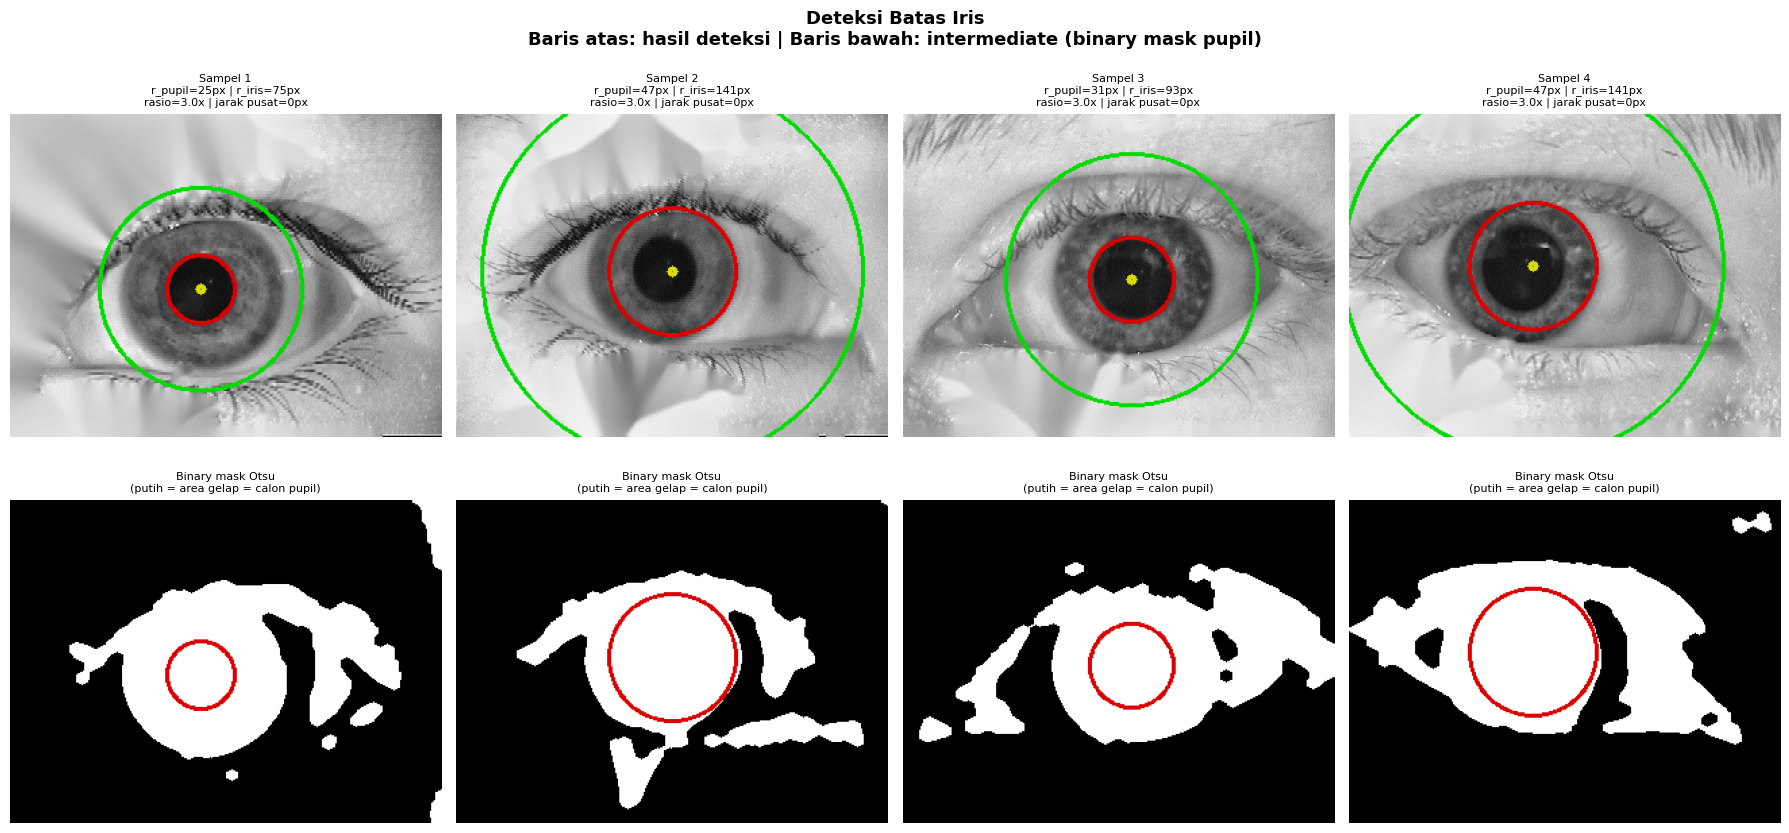

 Visualisasi tersimpan di Google Drive: /content/drive/MyDrive/Project_PCD/output/demo_deteksi_iris_v2.png

Keterangan:
  Lingkaran hijau = batas iris luar
  Lingkaran merah = batas pupil
  Titik kuning    = pusat pupil
  Garis kuning    = jarak pusat pupil-iris (harus pendek)
  Baris bawah     = binary mask Otsu (area putih = kandidat pupil)


In [ ]:
# Visualisasi & Evaluasi Deteksi

sample_images = []                                  # Ambil 4 gambar sampel dari processed_summary
for pid in list(processed_summary.keys())[:2]:
    for side in ['left', 'right']:
        imgs = processed_summary[pid]['train'][side]
        if imgs:
            sample_images.append(imgs[0])
        if len(sample_images) >= 4:
            break
    if len(sample_images) >= 4:
        break

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Deteksi Batas Iris\n'
             'Baris atas: hasil deteksi | Baris bawah: intermediate (binary mask pupil)',
             fontsize=13, fontweight='bold')

for i, img_path in enumerate(sample_images[:4]):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    pupil, iris = detect_iris_boundaries(img)                        # Deteksi

    blurred = cv2.GaussianBlur(img, (7, 7), 1.5)                      # visualisasi binary mask
    _, binary_mask = cv2.threshold(blurred, 0, 255,
                                   cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    img_vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)                        # Gambar hasil deteksi

    # Lingkaran iris (hijau)
    cv2.circle(img_vis, (iris[0], iris[1]), iris[2], (0, 220, 0), 2)

    # Lingkaran pupil (merah)
    cv2.circle(img_vis, (pupil[0], pupil[1]), pupil[2], (0, 0, 220), 2)

    # Titik pusat
    cv2.circle(img_vis, (pupil[0], pupil[1]), 4, (0, 220, 220), -1)

    # Garis dari pusat pupil ke pusat iris (untuk cek konsentrisitas)
    cv2.line(img_vis, (pupil[0], pupil[1]), (iris[0], iris[1]), (180, 180, 0), 1)

    axes[0, i].imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))           # Tampilkan di baris atas
    ratio = iris[2] / pupil[2] if pupil[2] > 0 else 0
    dist  = np.sqrt((iris[0]-pupil[0])**2 + (iris[1]-pupil[1])**2)
    axes[0, i].set_title(
        f'Sampel {i+1}\n'
        f'r_pupil={pupil[2]}px | r_iris={iris[2]}px\n'
        f'rasio={ratio:.1f}x | jarak pusat={dist:.0f}px',
        fontsize=8
    )
    axes[0, i].axis('off')

    mask_vis = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)              # Tampilkan binary mask di baris bawah
    cv2.circle(mask_vis, (pupil[0], pupil[1]), pupil[2], (0, 0, 220), 2)  # Overlay lingkaran pupil yang terdeteksi ke atas binary mask
    axes[1, i].imshow(cv2.cvtColor(mask_vis, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title(f'Binary mask Otsu\n(putih = area gelap = calon pupil)', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
save_path = os.path.join(OUTPUT_PATH, 'demo_deteksi_iris_v2.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f" Visualisasi tersimpan di Google Drive: {save_path}")
print()
print("Keterangan:")
print("  Lingkaran hijau = batas iris luar")
print("  Lingkaran merah = batas pupil")
print("  Titik kuning    = pusat pupil")
print("  Garis kuning    = jarak pusat pupil-iris (harus pendek)")
print("  Baris bawah     = binary mask Otsu (area putih = kandidat pupil)")


## Segmentasi Iris

Tujuan:
Mengisolasi **hanya area iris** dari keseluruhan gambar mata, membuang kelopak mata, bulu mata, pupil, dan latar belakang.

Cara kerja:
1. Mask berbentuk cincin (annular) antara batas pupil dan batas iris luar. Area ini adalah iris murni.
2. Menghaluskan tepi mask agar tidak kasar:
   - *Closing*: menutup lubang kecil di dalam mask
   - *Opening*: menghilangkan noise kecil di tepi mask
3. Kalikan mask dengan gambar asli. Piksel di luar mask menjadi 0 (hitam).

In [ ]:
def segment_iris(gray_img, pupil, iris_boundary):
    h, w = gray_img.shape

    mask_iris = np.zeros((h, w), dtype=np.uint8)                 # Buat mask lingkaran IRIS (penuh)
    cv2.circle(mask_iris,
               center=(iris_boundary[0], iris_boundary[1]),
               radius=iris_boundary[2],
               color=255,
               thickness=-1)  # -1 = isi penuh

    mask_pupil = np.zeros((h, w), dtype=np.uint8)                # Buat mask lingkaran PUPIL (untuk dikurangi)
    cv2.circle(mask_pupil,
               center=(pupil[0], pupil[1]),
               radius=pupil[2],
               color=255,
               thickness=-1)

                                                                 # Buat mask CINCIN (iris - pupil)
    mask_ring = cv2.subtract(mask_iris, mask_pupil)              # Mask iris dikurangi area pupil → bentuk cincin (annular)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))  # Operasi morfologi untuk memperhalus mask

    mask_ring = cv2.morphologyEx(mask_ring, cv2.MORPH_CLOSE, kernel) # Closing: menutup celah kecil di dalam mask

    mask_ring = cv2.morphologyEx(mask_ring, cv2.MORPH_OPEN, kernel) # Opening: menghilangkan noise/tonjolan kecil di tepi

                                                                    # Terapkan mask ke citra
    segmented = cv2.bitwise_and(gray_img, gray_img, mask=mask_ring) # Piksel di luar mask (nilai 0) akan menjadi hitam
    return mask_ring, segmented

  Iris fallback digunakan


/tmp/ipykernel_69034/4021798712.py:29: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_69034/4021798712.py:29: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_69034/4021798712.py:31: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_69034/4021798712.py:31: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  

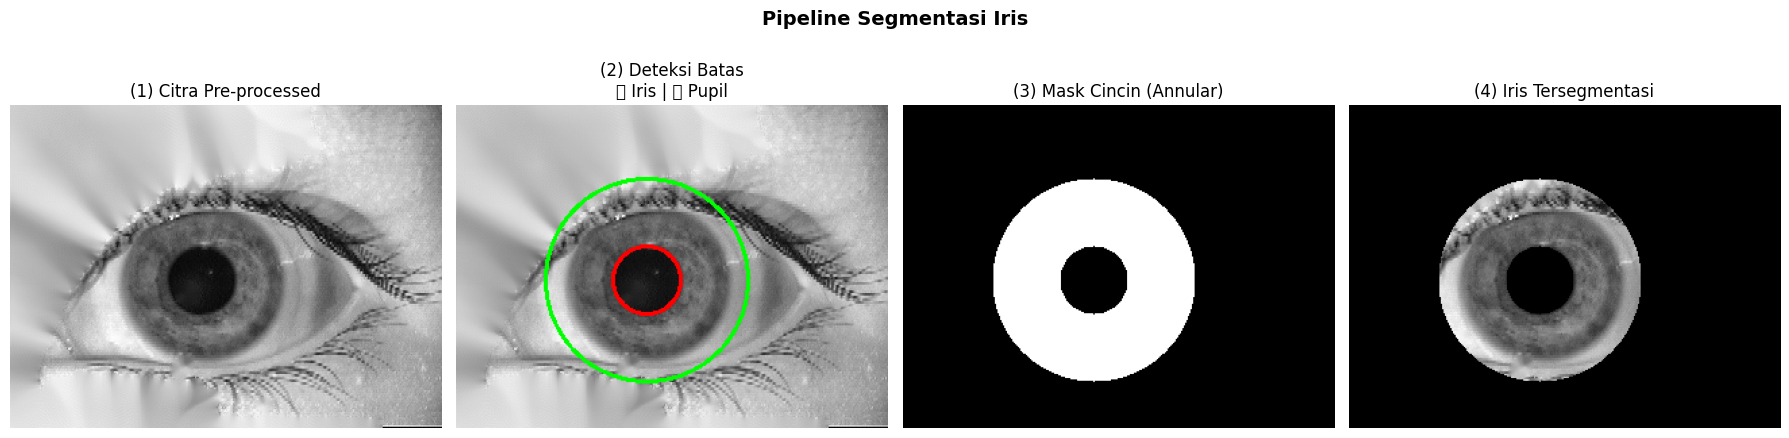

 Visualisasi tersimpan di Google Drive: /content/drive/MyDrive/Project_PCD/output/demo_segmentasi.png


In [ ]:
# Visualisasi pipeline: Preprocessed → Deteksi → Mask → Segmentasi

img_pp = cv2.imread(sample_images[0], cv2.IMREAD_GRAYSCALE)
pupil_demo, iris_demo = detect_iris_boundaries(img_pp)
mask_ring_demo, segmented_demo = segment_iris(img_pp, pupil_demo, iris_demo)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Pipeline Segmentasi Iris', fontsize=14, fontweight='bold')

axes[0].imshow(img_pp, cmap='gray')
axes[0].set_title('(1) Citra Pre-processed')
axes[0].axis('off')

img_vis = cv2.cvtColor(img_pp, cv2.COLOR_GRAY2BGR)
cv2.circle(img_vis, (iris_demo[0], iris_demo[1]),  iris_demo[2],  (0, 255, 0), 2)
cv2.circle(img_vis, (pupil_demo[0], pupil_demo[1]), pupil_demo[2], (0, 0, 255), 2)
axes[1].imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
axes[1].set_title('(2) Deteksi Batas\n🟢 Iris | 🔴 Pupil')
axes[1].axis('off')

axes[2].imshow(mask_ring_demo, cmap='gray')
axes[2].set_title('(3) Mask Cincin (Annular)')
axes[2].axis('off')

axes[3].imshow(segmented_demo, cmap='gray')
axes[3].set_title('(4) Iris Tersegmentasi')
axes[3].axis('off')

plt.tight_layout()
save_path = os.path.join(OUTPUT_PATH, 'demo_segmentasi.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f" Visualisasi tersimpan di Google Drive: {save_path}")


In [ ]:
# Proses segmentasi untuk SEMUA gambar

def segment_all_images(processed_summary, output_seg_path):
    seg_summary = {}
    boundaries  = {}  # Simpan batas pupil & iris untuk tahap normalisasi
    count = 0

    for person_id, splits in processed_summary.items():
        seg_summary[person_id] = {'train': {'left': [], 'right': []},
                                  'test':  {'left': [], 'right': []}}
        boundaries[person_id]  = {'train': {'left': [], 'right': []},
                                  'test':  {'left': [], 'right': []}}

        for split_name, sides in splits.items():
            for side, img_list in sides.items():
                out_dir = os.path.join(output_seg_path, split_name, person_id, side)
                os.makedirs(out_dir, exist_ok=True)

                for img_path in img_list:
                    try:
                        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                        pupil, iris_b = detect_iris_boundaries(img)
                        mask, segmented = segment_iris(img, pupil, iris_b)

                        fname    = os.path.basename(img_path)
                        out_path = os.path.join(out_dir, fname)
                        cv2.imwrite(out_path, segmented)

                        seg_summary[person_id][split_name][side].append(out_path)
                        boundaries[person_id][split_name][side].append(
                            {'pupil': pupil, 'iris': iris_b, 'src': img_path}
                        )
                        count += 1
                        if count % 50 == 0:
                            print(f"  Segmentasi: {count} gambar...")
                    except Exception as e:
                        print(f" Error pada {img_path}: {e}")

    return seg_summary, boundaries, count

print("   Hasil disimpan ke Google Drive...")
seg_summary, boundaries, n_segmented = segment_all_images(processed_summary, SEG_PATH)
print(f"\n Segmentasi selesai! Total: {n_segmented} gambar.")
print(f"   Tersimpan di: {SEG_PATH}")


   Hasil disimpan ke Google Drive...
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
  Iris fallback digunakan
 

## Normalisasi

Masalah yang diselesaikan:
Iris dari tiap gambar berbeda ukuran, posisi, dan pupil yang berdilatasi berbeda. Ini membuat perbandingan langsung tidak adil.

Solusi: Rubber Sheet Model (Daugman, 2002)
Bayangkan iris seperti **karet elastis** yang direntangkan dari bentuk cincin melingkar menjadi persegi panjang.

**Cara kerja matematis:**
- Setiap titik di iris dipetakan dari koordinat Cartesian (x, y) ke koordinat polar (r, θ)
- **θ (theta)**: sudut 0 sampai 2π (posisi melingkar di iris)
- **r (rho)**: jarak dinormalisasi 0-1 dari batas pupil ke batas iris luar

Formula pemetaan:
```
x(r, θ) = (1-r) · xp(θ) + r · xi(θ)
y(r, θ) = (1-r) · yp(θ) + r · yi(θ)
```

Di mana:
- `xp, yp` = koordinat di batas pupil pada sudut θ
- `xi, yi` = koordinat di batas iris luar pada sudut θ

**Hasil:** Gambar polar berukuran tetap (misal 64×512) — tinggi=radius, lebar=sudut.

In [ ]:
def daugman_rubber_sheet(gray_img, pupil, iris_boundary,
                          radial_resolution=64, angular_resolution=512):
    h, w = gray_img.shape

    px, py, r_pupil = pupil[0], pupil[1], pupil[2]                                  # Ekstrak koordinat
    ix, iy, r_iris  = iris_boundary[0], iris_boundary[1], iris_boundary[2]

    normalized = np.zeros((radial_resolution, angular_resolution), dtype=np.uint8)  # Inisialisasi citra output (kosong)

    # Grid sudut theta: 0 sampai 2π
    # angular_resolution titik yang terdistribusi merata di sekeliling lingkaran
    theta_values = np.linspace(0, 2 * np.pi, angular_resolution, endpoint=False)

    # Grid radial r: 0 (di batas pupil) sampai 1 (di batas iris luar)
    r_values = np.linspace(0, 1, radial_resolution)

    for ri, r in enumerate(r_values):                                               # Iterasi tiap kombinasi (r, θ)
        for ti, theta in enumerate(theta_values):
            # Koordinat di batas PUPIL pada sudut theta
            xp = px + r_pupil * np.cos(theta)   # x di batas pupil
            yp = py + r_pupil * np.sin(theta)   # y di batas pupil

            # Koordinat di batas IRIS LUAR pada sudut theta
            xi_coord = ix + r_iris * np.cos(theta)   # x di batas iris
            yi_coord = iy + r_iris * np.sin(theta)   # y di batas iris

            # Interpolasi linear antara batas pupil dan iris
            # r=0 → tepat di batas pupil
            # r=1 → tepat di batas iris luar
            x_sample = int((1 - r) * xp + r * xi_coord)
            y_sample = int((1 - r) * yp + r * yi_coord)

            # Pastikan koordinat dalam batas gambar
            if 0 <= x_sample < w and 0 <= y_sample < h:
                normalized[ri, ti] = gray_img[y_sample, x_sample]

    return normalized

def daugman_rubber_sheet_fast(gray_img, pupil, iris_boundary,                     # Versi yang lebih cepat menggunakan vectorization NumPy
                               radial_resolution=64, angular_resolution=512):
    h, w = gray_img.shape
    px, py, r_pupil = pupil[0], pupil[1], pupil[2]
    ix, iy, r_iris  = iris_boundary[0], iris_boundary[1], iris_boundary[2]

    # Buat meshgrid untuk semua kombinasi (r, θ) sekaligus
    theta = np.linspace(0, 2 * np.pi, angular_resolution, endpoint=False)
    r     = np.linspace(0, 1, radial_resolution)

    # Grid: R[i,j] = r[i], T[i,j] = theta[j]
    R, T = np.meshgrid(r, theta, indexing='ij')

    # Koordinat di batas pupil
    Xp = px + r_pupil * np.cos(T)
    Yp = py + r_pupil * np.sin(T)

    # Koordinat di batas iris
    Xi = ix + r_iris * np.cos(T)
    Yi = iy + r_iris * np.sin(T)

    # Interpolasi
    X_samp = ((1 - R) * Xp + R * Xi).astype(int)
    Y_samp = ((1 - R) * Yp + R * Yi).astype(int)

    # Kliping agar tidak keluar batas gambar
    X_samp = np.clip(X_samp, 0, w - 1)
    Y_samp = np.clip(Y_samp, 0, h - 1)

    # Sampling piksel
    normalized = gray_img[Y_samp, X_samp]

    return normalized

  Iris fallback digunakan


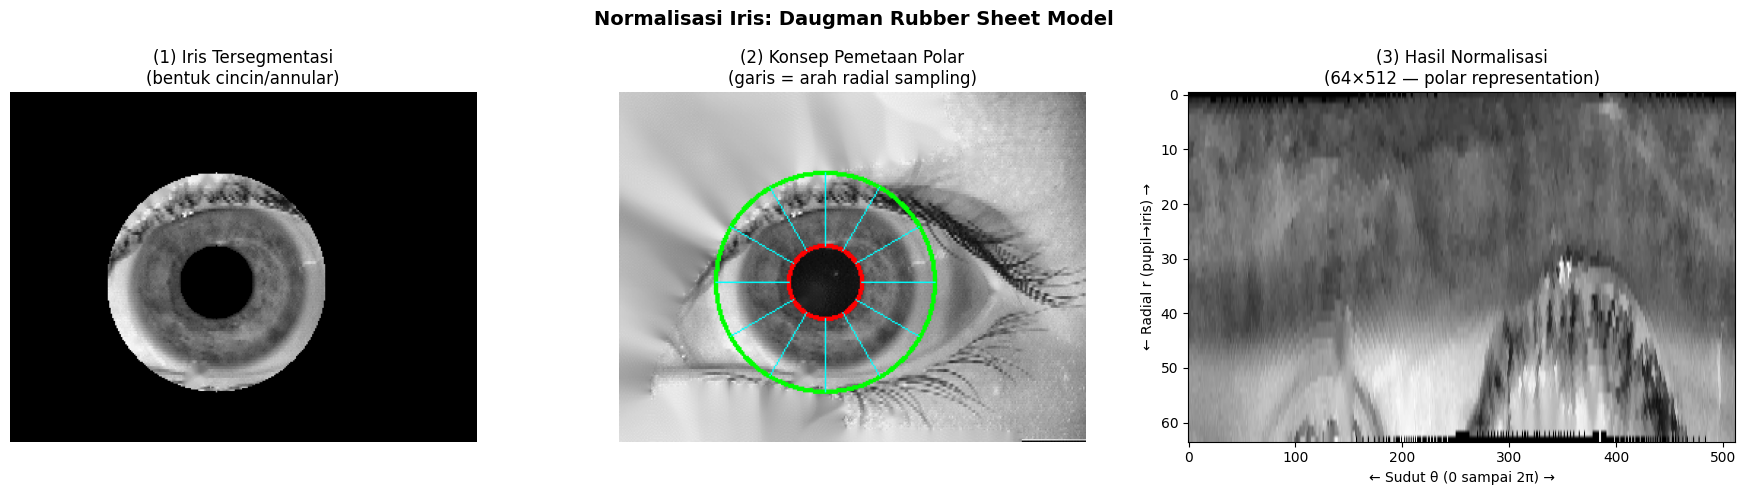

 Visualisasi tersimpan di Google Drive: /content/drive/MyDrive/Project_PCD/output/demo_normalisasi.png


In [ ]:
# Visualisasi Rubber Sheet Normalization

# Ambil gambar dari processed_summary (yang sudah preprocessed)
pid0 = list(processed_summary.keys())[0]
img_path_norm = processed_summary[pid0]['train']['left'][0]
img_for_norm  = cv2.imread(img_path_norm, cv2.IMREAD_GRAYSCALE)

pupil_n, iris_n   = detect_iris_boundaries(img_for_norm)
_, seg_for_norm    = segment_iris(img_for_norm, pupil_n, iris_n)
normalized_img     = daugman_rubber_sheet_fast(seg_for_norm, pupil_n, iris_n,
                                               radial_resolution=64,
                                               angular_resolution=512)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Normalisasi Iris: Daugman Rubber Sheet Model',
             fontsize=14, fontweight='bold')

axes[0].imshow(seg_for_norm, cmap='gray')
axes[0].set_title('(1) Iris Tersegmentasi\n(bentuk cincin/annular)')
axes[0].axis('off')

img_vis2 = cv2.cvtColor(img_for_norm, cv2.COLOR_GRAY2BGR)
cv2.circle(img_vis2, (iris_n[0], iris_n[1]),  iris_n[2],  (0, 255, 0), 2)
cv2.circle(img_vis2, (pupil_n[0], pupil_n[1]), pupil_n[2], (0, 0, 255), 2)
for angle_deg in range(0, 360, 30):
    angle_rad = np.radians(angle_deg)
    x1 = int(pupil_n[0] + pupil_n[2] * np.cos(angle_rad))
    y1 = int(pupil_n[1] + pupil_n[2] * np.sin(angle_rad))
    x2 = int(iris_n[0]  + iris_n[2]  * np.cos(angle_rad))
    y2 = int(iris_n[1]  + iris_n[2]  * np.sin(angle_rad))
    cv2.line(img_vis2, (x1, y1), (x2, y2), (255, 255, 0), 1)
axes[1].imshow(cv2.cvtColor(img_vis2, cv2.COLOR_BGR2RGB))
axes[1].set_title('(2) Konsep Pemetaan Polar\n(garis = arah radial sampling)')
axes[1].axis('off')

axes[2].imshow(normalized_img, cmap='gray', aspect='auto')
axes[2].set_title('(3) Hasil Normalisasi\n(64×512 — polar representation)')
axes[2].set_xlabel('← Sudut θ (0 sampai 2π) →')
axes[2].set_ylabel('← Radial r (pupil→iris) →')

plt.tight_layout()
save_path = os.path.join(OUTPUT_PATH, 'demo_normalisasi.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f" Visualisasi tersimpan di Google Drive: {save_path}")


In [ ]:
# Normalisasi Rubber Sheet untuk SEMUA gambar

def normalize_all_images(seg_summary, boundaries, output_norm_path,
                          radial_res=64, angular_res=512):
    norm_summary = {}
    count = 0

    for person_id in seg_summary.keys():
        norm_summary[person_id] = {'train': {'left': [], 'right': []},
                                   'test':  {'left': [], 'right': []}}

        for split_name in ['train', 'test']:
            for side in ['left', 'right']:
                img_list = seg_summary[person_id][split_name][side]
                bnd_list = boundaries[person_id][split_name][side]

                out_dir = os.path.join(output_norm_path, split_name, person_id, side)
                os.makedirs(out_dir, exist_ok=True)

                for img_path, bnd in zip(img_list, bnd_list):
                    try:
                        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                        normalized = daugman_rubber_sheet_fast(
                            img, bnd['pupil'], bnd['iris'],
                            radial_resolution=radial_res,
                            angular_resolution=angular_res
                        )
                        fname    = os.path.basename(img_path)
                        out_path = os.path.join(out_dir, fname)
                        cv2.imwrite(out_path, normalized)
                        norm_summary[person_id][split_name][side].append(out_path)
                        count += 1
                        if count % 50 == 0:
                            print(f"  Normalisasi: {count} gambar...")
                    except Exception as e:
                        print(f" Error pada {img_path}: {e}")

    return norm_summary, count

print("   Hasil disimpan ke Google Drive...")
norm_summary, n_normalized = normalize_all_images(seg_summary, boundaries, NORM_PATH)
print(f"\n Normalisasi selesai! Total: {n_normalized} gambar.")
print(f"   Tersimpan di: {NORM_PATH}")


   Hasil disimpan ke Google Drive...
  Normalisasi: 50 gambar...
  Normalisasi: 100 gambar...
  Normalisasi: 150 gambar...
  Normalisasi: 200 gambar...
  Normalisasi: 250 gambar...
  Normalisasi: 300 gambar...
  Normalisasi: 350 gambar...
  Normalisasi: 400 gambar...
  Normalisasi: 450 gambar...

 Normalisasi selesai! Total: 450 gambar.
   Tersimpan di: /content/drive/MyDrive/Project_PCD/output/normalized


## Augmentasi Data

**1. Horizontal Shift (Pergeseran Horizontal)**
> Karena citra iris sudah dinormalisasi ke bentuk polar, pergeseran horizontal **setara dengan rotasi angular** di iris asli. Ini mensimulasikan variasi posisi kamera yang sedikit berputar. Augmentasi ini secara geometri bermakna untuk citra iris.

**2. Brightness Variation (Variasi Kecerahan)**
> Mensimulasikan kondisi pencahayaan yang berbeda (redup/terang). Dilakukan dengan mengalikan nilai piksel dengan faktor (>1 = lebih terang, <1 = lebih gelap).

In [ ]:
def augment_horizontal_shift(img, shift_range=0.1):

    h, w = img.shape[:2]

    max_shift = int(w * shift_range)
    shift_px  = random.randint(-max_shift, max_shift)
    shifted = np.roll(img, shift_px, axis=1)

    return shifted, shift_px

def augment_brightness(img, factor_range=(0.7, 1.3)):

    factor = random.uniform(factor_range[0], factor_range[1])
    brightened = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

    return brightened, factor

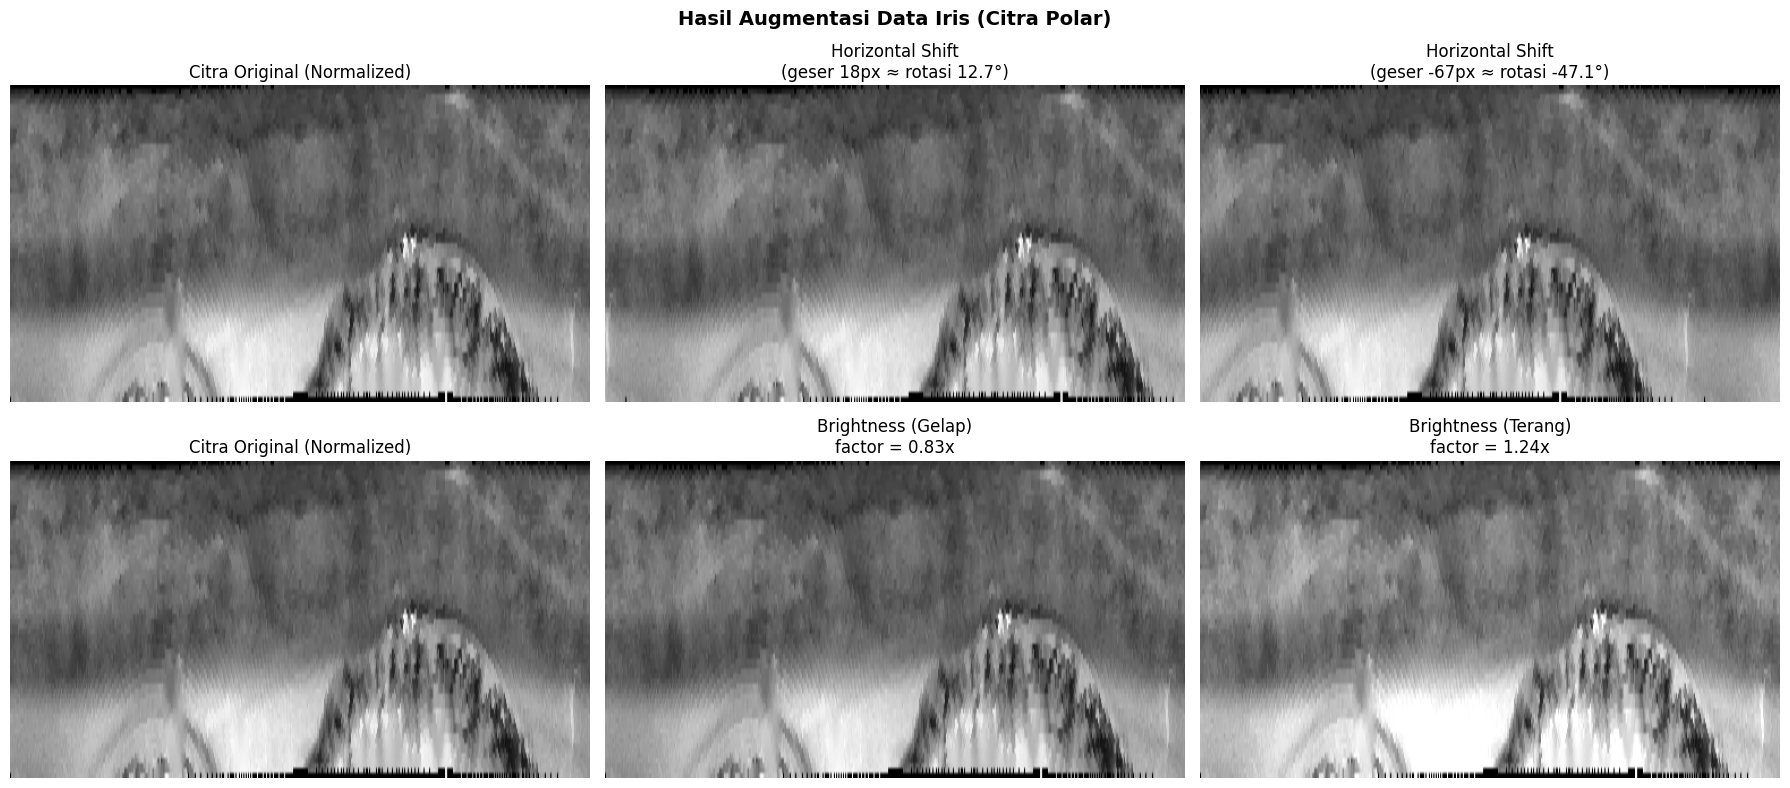

 Visualisasi tersimpan di Google Drive: /content/drive/MyDrive/Project_PCD/output/demo_augmentasi.png


In [ ]:
# Visualisasi augmentasi pada 1 gambar sampel

pid0 = list(norm_summary.keys())[0]
norm_sample_path = norm_summary[pid0]['train']['left'][0]
norm_sample = cv2.imread(norm_sample_path, cv2.IMREAD_GRAYSCALE)

shifted_1, s1 = augment_horizontal_shift(norm_sample, shift_range=0.10)          # Generate beberapa variasi
shifted_2, s2 = augment_horizontal_shift(norm_sample, shift_range=0.15)          # Augmentasi shifted ada 2 dan augmentasi bright ada 2
bright_1,  f1 = augment_brightness(norm_sample, factor_range=(0.7, 0.85))
bright_2,  f2 = augment_brightness(norm_sample, factor_range=(1.15, 1.30))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Hasil Augmentasi Data Iris (Citra Polar)', fontsize=14, fontweight='bold')

axes[0, 0].imshow(norm_sample, cmap='gray', aspect='auto')
axes[0, 0].set_title('Citra Original (Normalized)')
axes[0, 0].axis('off')

axes[0, 1].imshow(shifted_1, cmap='gray', aspect='auto')
axes[0, 1].set_title(f'Horizontal Shift\n(geser {s1}px ≈ rotasi {s1/512*360:.1f}°)')
axes[0, 1].axis('off')

axes[0, 2].imshow(shifted_2, cmap='gray', aspect='auto')
axes[0, 2].set_title(f'Horizontal Shift\n(geser {s2}px ≈ rotasi {s2/512*360:.1f}°)')
axes[0, 2].axis('off')

axes[1, 0].imshow(norm_sample, cmap='gray', aspect='auto')
axes[1, 0].set_title('Citra Original (Normalized)')
axes[1, 0].axis('off')

axes[1, 1].imshow(bright_1, cmap='gray', aspect='auto')
axes[1, 1].set_title(f'Brightness (Gelap)\nfactor = {f1:.2f}x')
axes[1, 1].axis('off')

axes[1, 2].imshow(bright_2, cmap='gray', aspect='auto')
axes[1, 2].set_title(f'Brightness (Terang)\nfactor = {f2:.2f}x')
axes[1, 2].axis('off')

plt.tight_layout()
save_path = os.path.join(OUTPUT_PATH, 'demo_augmentasi.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f" Visualisasi tersimpan di Google Drive: {save_path}")


In [ ]:
# Augmentasi untuk SEMUA gambar TRAINING (bukan test!)
# Augmentasi HANYA pada data train untuk test harus tetap asli

def augment_all_train_images(norm_summary, output_aug_path, n_augment_per_image=2):
    aug_summary = {}
    count_aug   = 0
    count_orig  = 0

    for person_id, splits in norm_summary.items():
        aug_summary[person_id] = {'train': {'left': [], 'right': []},
                                  'test':  splits['test']}  # Test: tidak diaugmentasi

        for side in ['left', 'right']:
            img_list = splits['train'][side]
            out_dir  = os.path.join(output_aug_path, 'train', person_id, side)
            os.makedirs(out_dir, exist_ok=True)

            for img_path in img_list:
                img   = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                fname = os.path.splitext(os.path.basename(img_path))[0]
                ext   = os.path.splitext(img_path)[1]

                orig_path = os.path.join(out_dir, f"{fname}_orig{ext}")                 # Simpan gambar ORIGINAL
                cv2.imwrite(orig_path, img)
                aug_summary[person_id]['train'][side].append(orig_path)
                count_orig += 1

                for aug_i in range(n_augment_per_image):                                # Augmentasi: Horizontal Shift
                    aug_img, _ = augment_horizontal_shift(img, shift_range=0.12)
                    aug_path   = os.path.join(out_dir, f"{fname}_hshift{aug_i}{ext}")
                    cv2.imwrite(aug_path, aug_img)
                    aug_summary[person_id]['train'][side].append(aug_path)
                    count_aug += 1

                for aug_i in range(n_augment_per_image):                                 # Augmentasi: Brightness
                    aug_img, _ = augment_brightness(img, factor_range=(0.7, 1.3))
                    aug_path   = os.path.join(out_dir, f"{fname}_bright{aug_i}{ext}")
                    cv2.imwrite(aug_path, aug_img)
                    aug_summary[person_id]['train'][side].append(aug_path)
                    count_aug += 1

        if count_orig % 100 == 0 and count_orig > 0:
            print(f"  Augmentasi: {count_orig} orig + {count_aug} augmented")

    return aug_summary, count_orig, count_aug


print("   Hasil disimpan ke Google Drive...")
aug_summary, n_orig, n_aug = augment_all_train_images(
    norm_summary, AUG_PATH, n_augment_per_image=2
)

total_train_aug = n_orig + n_aug
print(f"\n HASIL AUGMENTASI")
print("=" * 45)
print(f"Gambar training asli    : {n_orig}")
print(f"Gambar hasil augmentasi : {n_aug}")
print(f"Total data training     : {total_train_aug} gambar")
print(f"Peningkatan data        : {total_train_aug/n_orig:.1f}x lebih banyak")
print()
print(f"   Augmentasi selesai!")
print(f"   Tersimpan di: {AUG_PATH}")


   Hasil disimpan ke Google Drive...
  Augmentasi: 200 orig + 800 augmented

 HASIL AUGMENTASI
Gambar training asli    : 360
Gambar hasil augmentasi : 1440
Total data training     : 1800 gambar
Peningkatan data        : 5.0x lebih banyak

   Augmentasi selesai!
   Tersimpan di: /content/drive/MyDrive/Project_PCD/output/augmented


# Load Data Augmentasi

In [ ]:
import os
import cv2
import numpy as np
import glob
from google.colab import drive

# 1. Mount Drive (Wajib dijalankan jika membuka sesi/runtime baru)
drive.mount('/content/drive')

# 2. Definisikan path utama
PROJECT_ROOT = '/content/drive/MyDrive/Projek_PCD'
AUG_PATH = os.path.join(PROJECT_ROOT, 'output', 'augmented')
NORM_PATH = os.path.join(PROJECT_ROOT, 'output', 'normalized')

def load_dataset_for_modeling(data_path, split_type):
    images = []
    labels = []

    # Format folder: path / split_type / person_id / side / image.ext
    # Contoh: .../augmented/train/1/left/img.jpg
    search_path = os.path.join(data_path, split_type, "*", "*", "*.*")
    file_list = glob.glob(search_path)

    for file_path in file_list:
        # Ekstrak label (person_id) dari path
        # Dari path di atas, person_id ada di folder ke-3 dari belakang
        person_id = file_path.split(os.sep)[-3]

        # Baca gambar dalam grayscale
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
            labels.append(person_id)

    return np.array(images), np.array(labels)

# 3. Load data Train dan Test ke dalam array
print("Memuat data Train (dari folder Augmented)...")
X_train, y_train = load_dataset_for_modeling(AUG_PATH, 'train')

print("Memuat data Test (dari folder Normalized)...")
# Catatan: Karena test set tidak diaugmentasi, kita ambil langsung dari folder 'normalized'
X_test, y_test = load_dataset_for_modeling(NORM_PATH, 'test')

print("-" * 30)
print(f"Data siap! Total Train: {len(X_train)} gambar, Total Test: {len(X_test)} gambar.")
# Sekarang X_train dan y_train sudah siap dimasukkan ke model

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Memuat data Train (dari folder Augmented)...
Memuat data Test (dari folder Normalized)...
------------------------------
Data siap! Total Train: 0 gambar, Total Test: 0 gambar.


# LOG GABOR + SVM

In [ ]:
from scipy.fftpack import fft2, ifft2, fftshift
from scipy.stats import entropy

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns

## LOG GABOR

In [ ]:
print(f"   Tersimpan di: {AUG_PATH}")

   Tersimpan di: /content/drive/MyDrive/Projek_PCD/output/augmented


In [ ]:
from scipy.fftpack import fft2, ifft2, fftshift

### Log Gabor Filter

In [ ]:
def log_gabor_filter(
    shape,
    f0=0.15,
    theta=0,
    sigma=0.55
):

    rows, cols = shape

    y, x = np.mgrid[
        -rows//2:rows//2,
        -cols//2:cols//2
    ]

    radius = np.sqrt(
        x**2 + y**2
    )

    angle = np.arctan2(
        y,
        x
    )

    radius[
        rows//2,
        cols//2
    ] = 1

    radius = (
        radius /
        radius.max()
    )

    radial = np.exp(

        -(
            np.log(
                radius / f0
            )**2
        )

        /

        (
            2 *
            (
                np.log(
                    sigma
                )**2
            )
        )

    )

    angular = np.exp(

        -(
            (angle - theta)**2
        )

        /

        (
            2 *
            (
                np.pi/8
            )**2
        )

    )

    lg = radial * angular

    lg[
        rows//2,
        cols//2
    ] = 0

    return fftshift(lg)

### Ekstraksi Fitur Log-Gabor

In [ ]:
def extract_log_gabor_features(img):

    img = img.astype(np.float32) / 255.0

    frequencies = [
        0.03,
        0.06,
        0.09,
        0.12,
        0.15,
        0.18
    ]

    orientations = [
        0,
        np.pi/4,
        np.pi/2,
        3*np.pi/4,
        np.pi/6,
        np.pi/3,
        (2 * np.pi) / 3,
        (5 * np.pi) / 6
    ]

    features = []

    F = fft2(img)

    for freq in frequencies:

        for theta in orientations:

            lg = log_gabor_filter(
                img.shape,
                f0=freq,
                theta=theta
            )

            response = np.abs(
                ifft2(F * lg)
            )

            h, w = response.shape

            blocks = [

                response[:h//2, :w//2],     # kiri atas

                response[:h//2, w//2:],     # kanan atas

                response[h//2:, :w//2],     # kiri bawah

                response[h//2:, w//2:]      # kanan bawah

            ]

            for block in blocks:

                mean_val = np.mean(block)

                var_val = np.var(block)

                energy_val = np.sum(
                    block ** 2
                )

                hist, _ = np.histogram(
                    block,
                    bins=64,
                    density=True
                )

                entropy_val = entropy(
                    hist + 1e-10
                )

                max_val = np.max(block)

                min_val = np.min(block)

                features.extend([

                    mean_val,

                    var_val,

                    energy_val,

                    entropy_val,

                    max_val,

                    min_val

                ])

    return np.array(
        features,
        dtype=np.float32
    )

### Build Dataset Train

##### Train Dataset

In [ ]:
def build_loggabor_train_dataset(
    aug_summary
):

    X = []
    y = []

    total = 0

    for person_id, splits in aug_summary.items():

        for side in [
            'left',
            'right'
        ]:

            for img_path in splits['train'][side]:

                img = cv2.imread(
                    img_path,
                    cv2.IMREAD_GRAYSCALE
                )

                if img is None:
                    continue

                feat = extract_log_gabor_features(
                    img
                )

                X.append(feat)

                y.append(person_id)

                total += 1

                if total % 100 == 0:
                    print(
                        f"{total} gambar selesai"
                    )

    return np.array(X), np.array(y)

##### Generate Train Dataset

In [ ]:
X_train_loggabor, y_train_loggabor = build_loggabor_train_dataset(
    aug_summary
)

print(X_train_loggabor.shape)

100 gambar selesai
200 gambar selesai
300 gambar selesai
400 gambar selesai
500 gambar selesai
600 gambar selesai
700 gambar selesai
800 gambar selesai
900 gambar selesai
1000 gambar selesai
1100 gambar selesai
1200 gambar selesai
1300 gambar selesai
1400 gambar selesai
1500 gambar selesai
1600 gambar selesai
1700 gambar selesai
1800 gambar selesai
(1800, 1152)


### Build Dataset Testing

##### Test Dataset

In [ ]:
def build_loggabor_test_dataset(
    aug_summary
):

    X = []
    y = []

    for person_id, splits in aug_summary.items():

        for side in [
            'left',
            'right'
        ]:

            for img_path in splits['test'][side]:

                img = cv2.imread(
                    img_path,
                    cv2.IMREAD_GRAYSCALE
                )

                if img is None:
                    continue

                feat = extract_log_gabor_features(
                    img
                )

                X.append(feat)

                y.append(person_id)

    return np.array(X), np.array(y)

##### Generate Test Dataset

In [ ]:
X_test_loggabor, y_test_loggabor = build_loggabor_test_dataset(
    aug_summary
)

print(X_test_loggabor.shape)

(90, 1152)


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_loggabor
)

X_test_scaled = scaler.transform(
    X_test_loggabor
)

### Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(
    y_train_loggabor
)

y_test_enc = le.transform(
    y_test_loggabor
)

## SVM

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

### Train SVM

Menggunakan Support Vector Classification (SVC)
dengan kernel Radial Basis Function (RBF).

Strategi multiclass yang digunakan adalah
One-vs-One (OvO). Grid Search SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {

    'C': [1, 10, 50, 100],

    'gamma': [
        'scale',
        0.1,
        0.01,
        0.001
    ],

    'kernel': ['rbf']

}

grid = GridSearchCV(

    SVC(),

    param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1

)

grid.fit(
    X_train_scaled,
    y_train_enc
)

print(grid.best_params_)

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


### Model Terbaik

In [ ]:
svm_model = grid.best_estimator_

## Evaluasi Model

In [ ]:
svm_model = grid.best_estimator_

y_pred = svm_model.predict(
    X_test_scaled
)

## Akurasi

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_test_enc,
    y_pred
)

print(
    f"Akurasi SVM : {acc:.4f}"
)

Akurasi SVM : 0.6667


## Report

In [ ]:
print(
    classification_report(
        y_test_enc,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       1.00      0.50      0.67         2
           2       1.00      0.50      0.67         2
           3       0.00      0.00      0.00         2
           4       0.67      1.00      0.80         2
           5       0.33      0.50      0.40         2
           6       1.00      0.50      0.67         2
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       0.33      0.50      0.40         2
          12       1.00      1.00      1.00         2
          13       0.00      0.00      0.00         2
          14       1.00      0.50      0.67         2
          15       1.00      0.50      0.67         2
          16       1.00      1.00      1.00         2
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

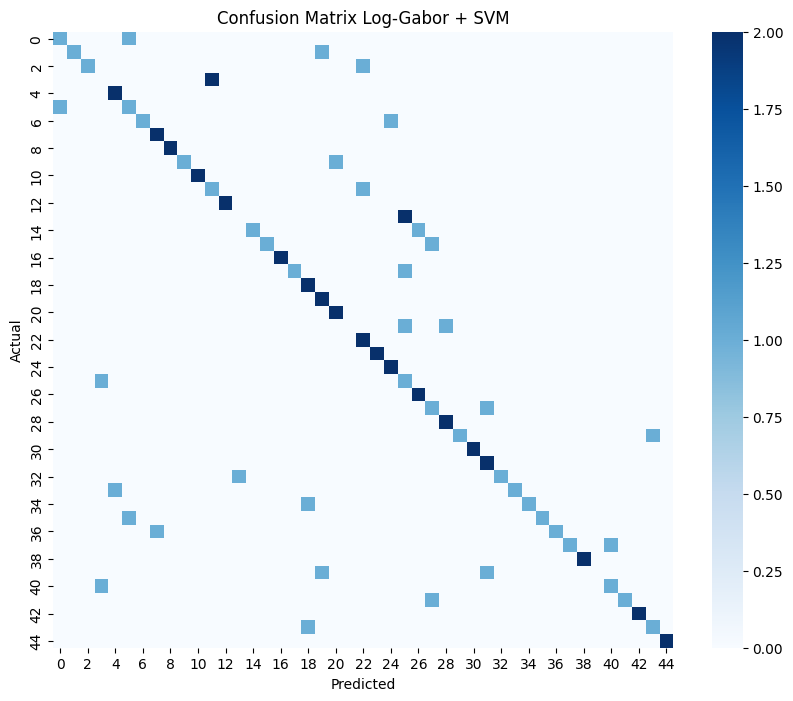

In [ ]:
cm = confusion_matrix(
    y_test_enc,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title(
    'Confusion Matrix Log-Gabor + SVM'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()